# check if the default multi-variate fourier analysis tools give some visualisation and insight to the data set.

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

cpu


In [2]:
puck_list = ['Puck_230517_39'] # the largest puck
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1",
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr",
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
head = 0
adata, X,Y, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)

['Lhb', 'Cga'] dropped from gene_list due to not being observed.


In [3]:
X.shape

torch.Size([15907, 2])

In [4]:
Y.shape

torch.Size([15907, 22])

In [5]:
import torch
import numpy as np

# Step 1: Fourier Transform for Features (Y)
Y_fft = torch.fft.fft(Y, dim=0)  # Fourier transform along the feature axis
Y_fft_magnitude = torch.abs(Y_fft)  # Magnitude of the Fourier transform
Y_fft_phase = torch.angle(Y_fft)  # Phase of the Fourier transform

# Step 2: Fourier Transform for Spatial Coordinates (X)
# To perform a spatial Fourier Transform, we may need to bin spatial data into a grid.
# For simplicity, assume spatial data is uniformly distributed on a 2D grid.
# Create a 2D grid from X
grid_size = 256  # Define grid size for interpolation
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

# Create grid
x_bins = torch.linspace(x_min, x_max, grid_size)
y_bins = torch.linspace(y_min, y_max, grid_size)
x_grid, y_grid = torch.meshgrid(x_bins, y_bins)

# Interpolate data into the grid (requires PyTorch GridData or Scipy's griddata)
from scipy.interpolate import griddata

# Interpolate Y to the grid based on X
Y_grid = np.zeros((grid_size, grid_size, 22))  # Initialize interpolated grid
for feature_idx in range(22):
    Y_grid[:, :, feature_idx] = griddata(
        X.numpy(),
        Y[:, feature_idx].numpy(),
        (x_grid.numpy(), y_grid.numpy()),
        method='linear',
        fill_value=0
    )

# Perform 2D Fourier Transform on each feature
Y_grid_fft = np.fft.fft2(Y_grid, axes=(0, 1))  # Fourier transform on 2D spatial grid
Y_grid_fft_magnitude = np.abs(Y_grid_fft)
Y_grid_fft_phase = np.angle(Y_grid_fft)

# Step 3: Analyze Spectral Densities (Optional)
# Example: Compute cross-spectral density between the first two features
cross_spectral_density = (
    np.fft.fft2(Y_grid[:, :, 0]) * np.conj(np.fft.fft2(Y_grid[:, :, 1]))
)

# Magnitude of cross-spectral density
cross_spectral_density_magnitude = np.abs(cross_spectral_density)

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538439675/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


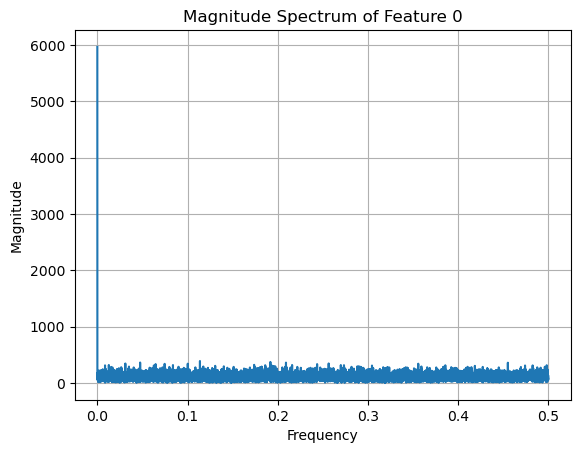

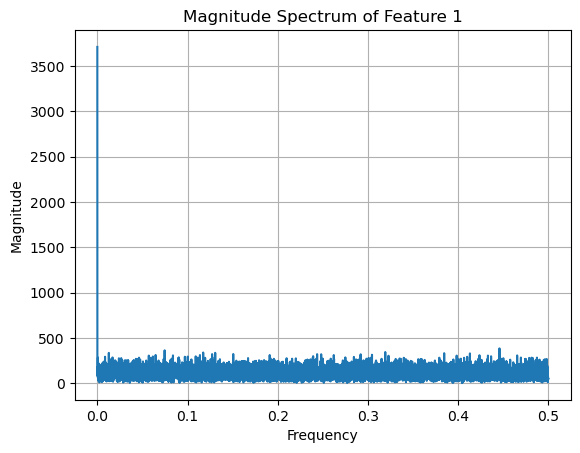

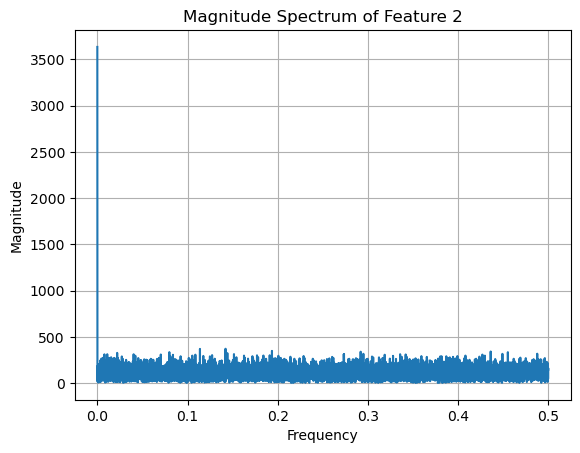

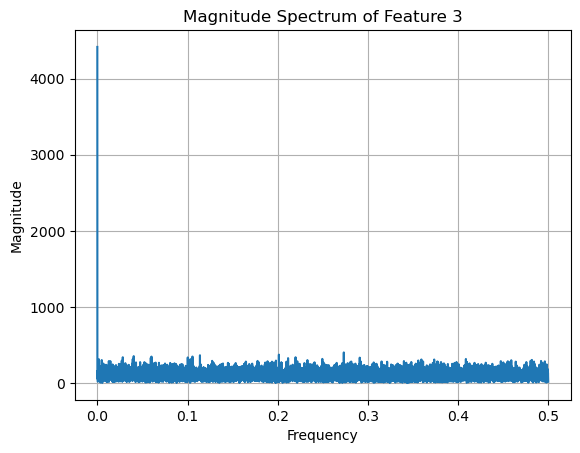

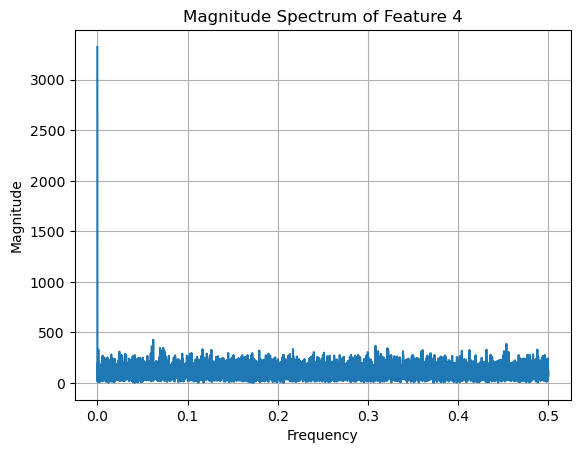

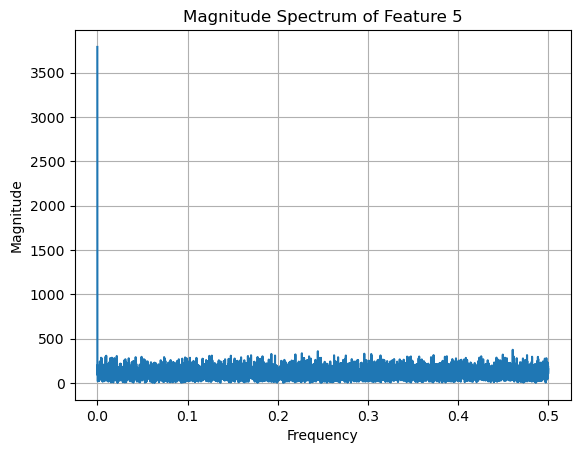

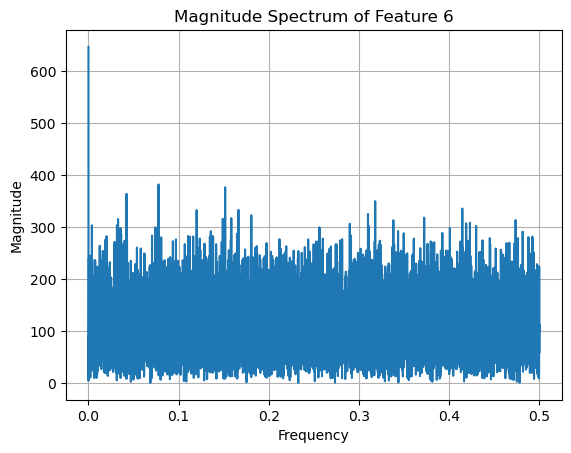

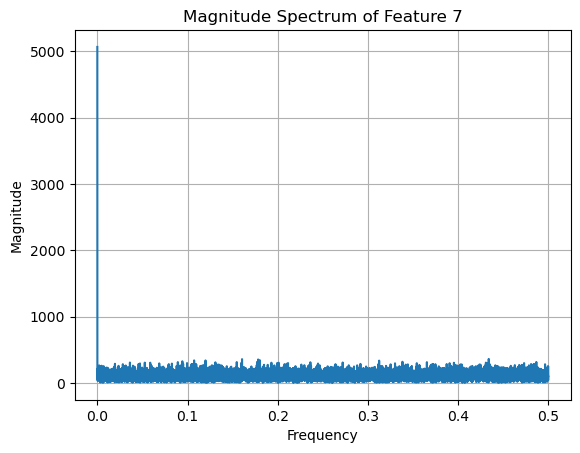

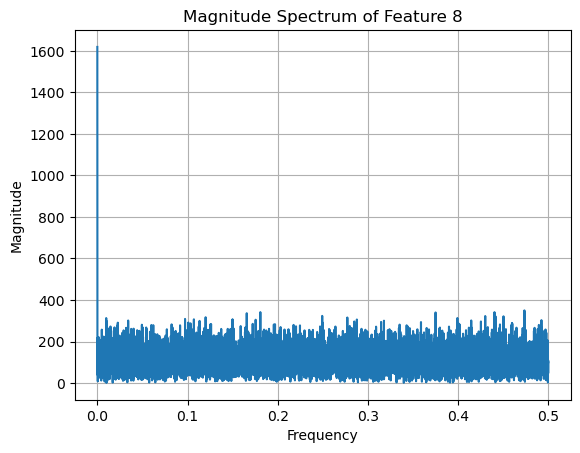

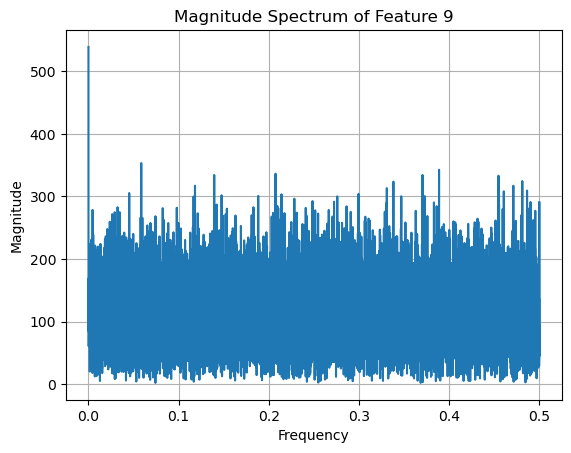

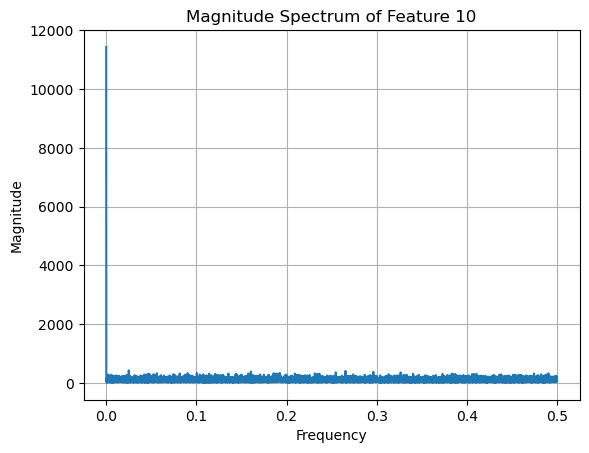

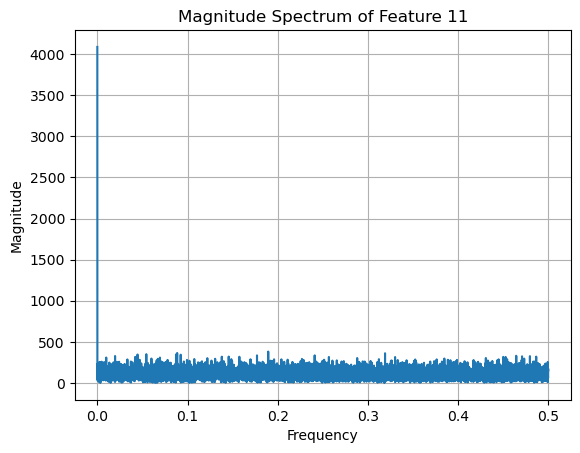

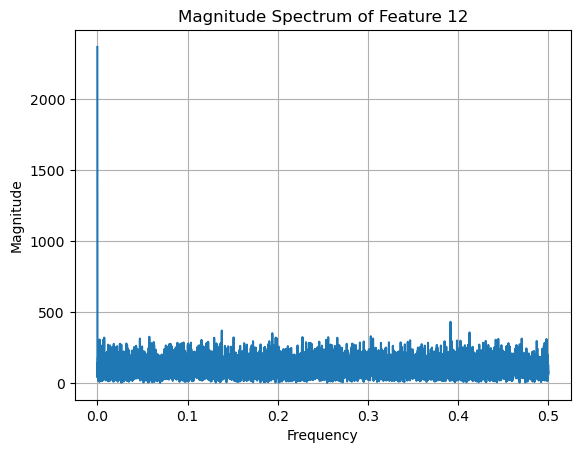

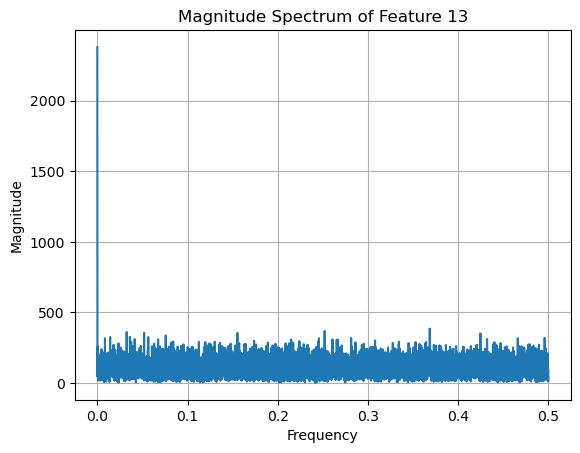

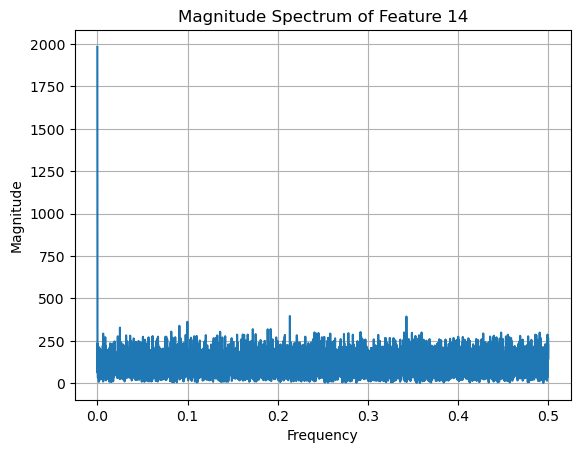

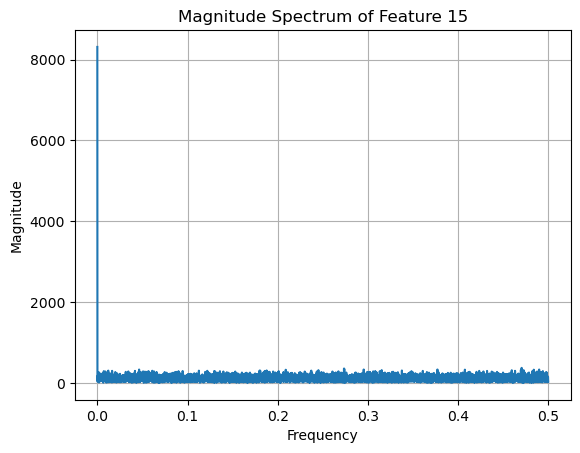

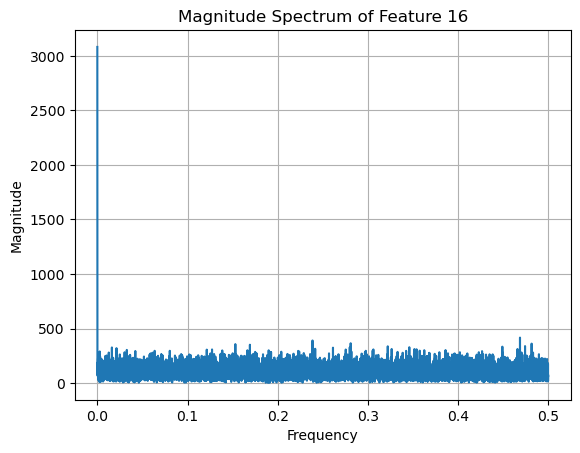

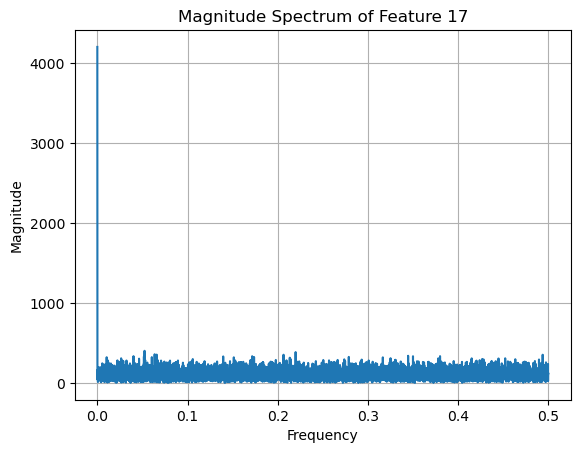

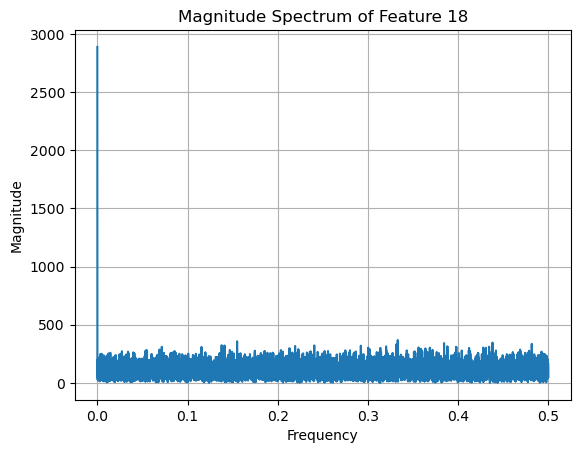

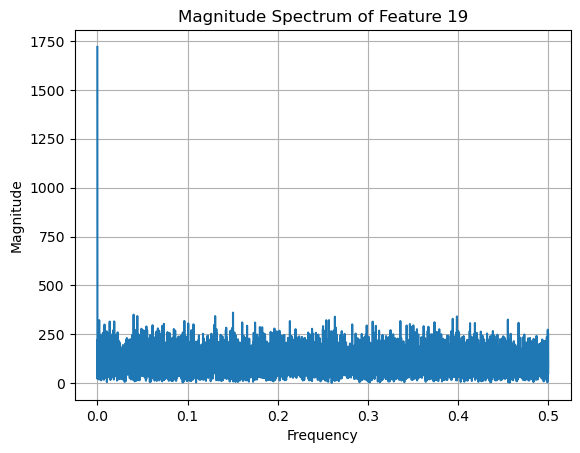

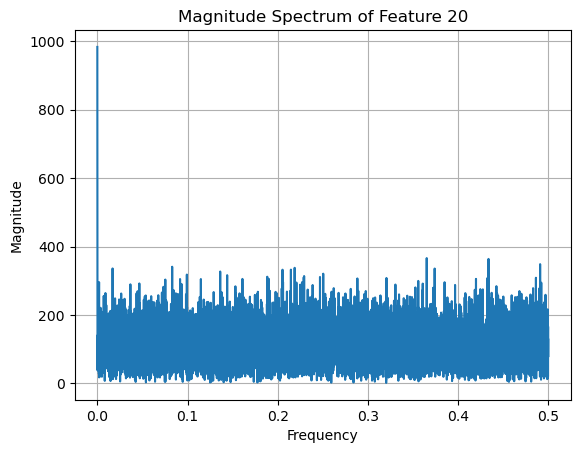

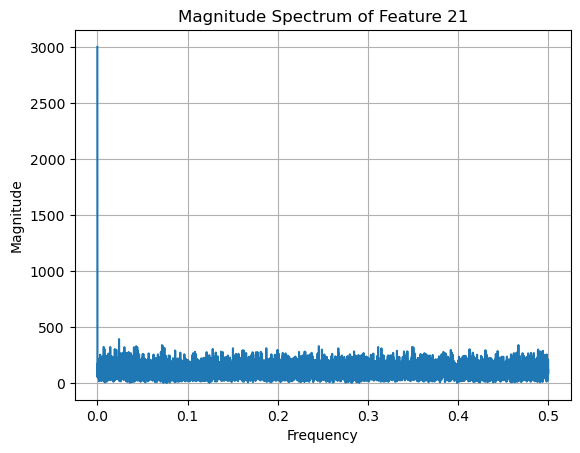

In [6]:
import matplotlib.pyplot as plt

# Frequency components
freqs = torch.fft.fftfreq(Y.shape[0])

# Plot magnitude spectrum for a sample feature
for j in range(Y.shape[1]):
    plt.figure()
    plt.plot(freqs[:len(freqs)//2], Y_fft_magnitude[:len(freqs)//2, j].numpy())
    plt.title(f'Magnitude Spectrum of Feature {j}')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()


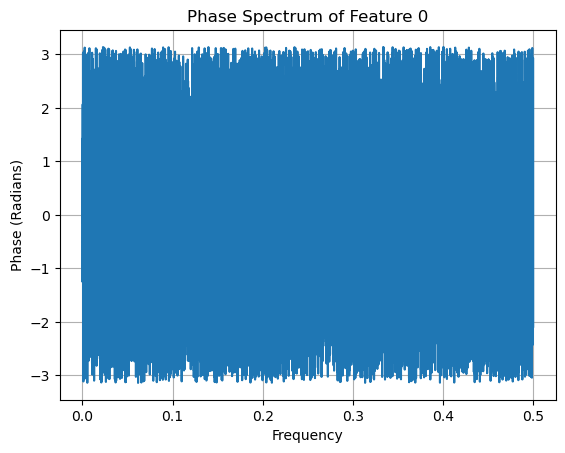

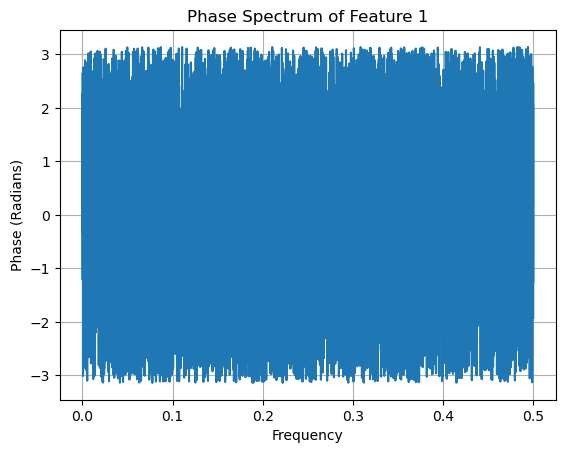

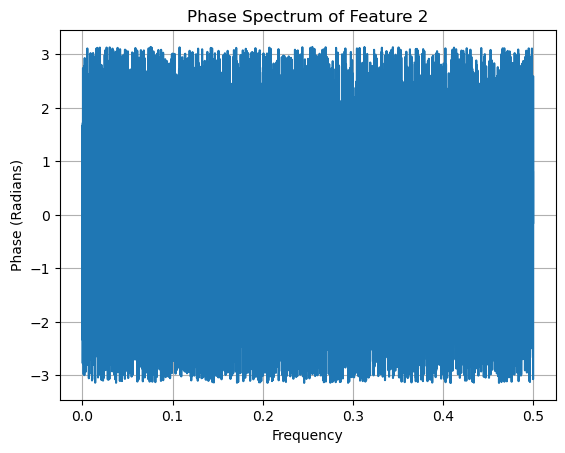

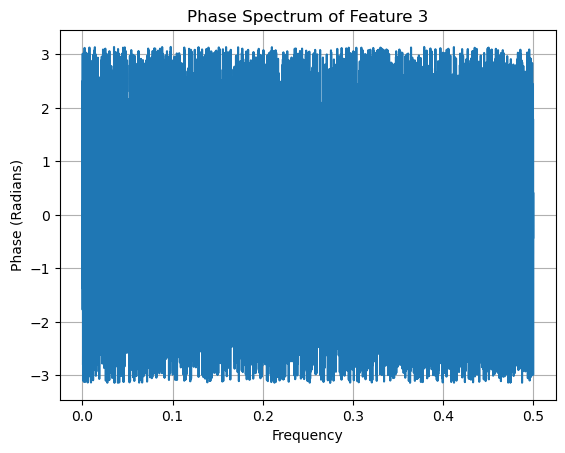

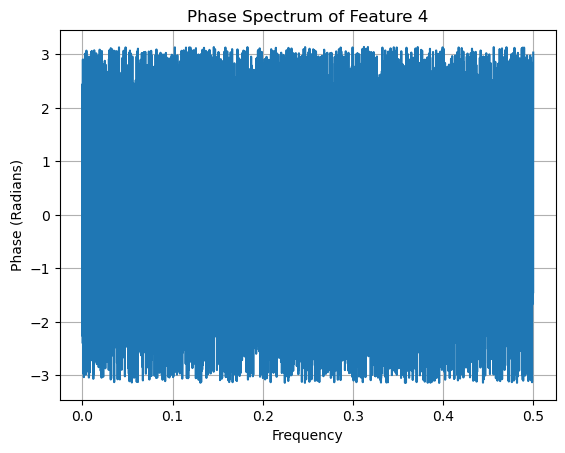

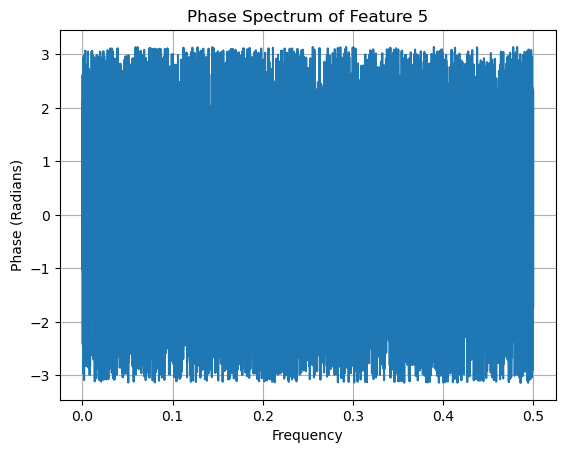

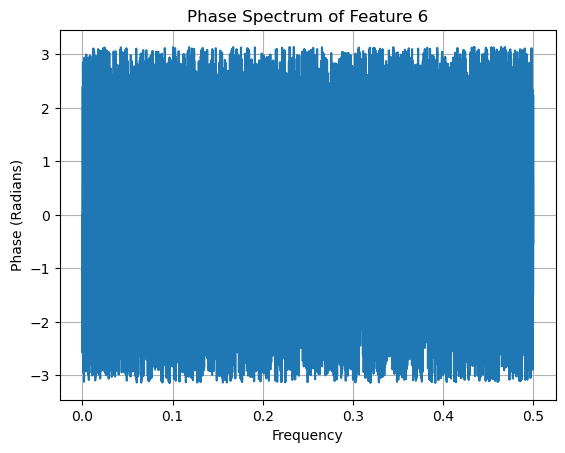

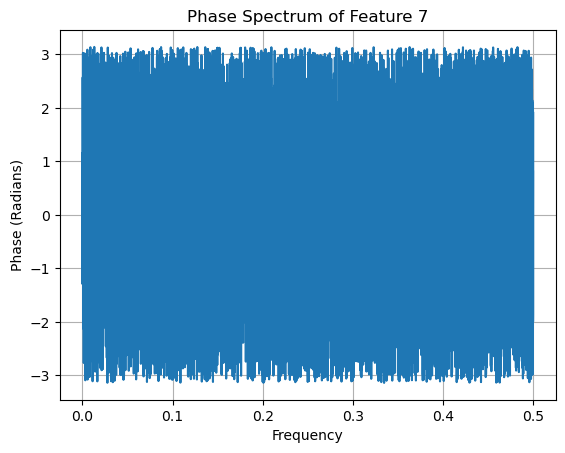

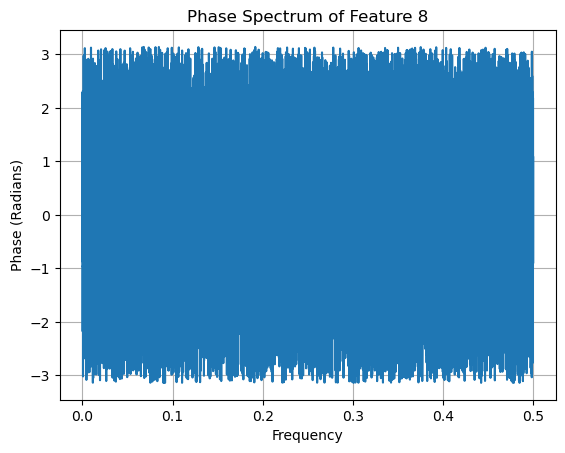

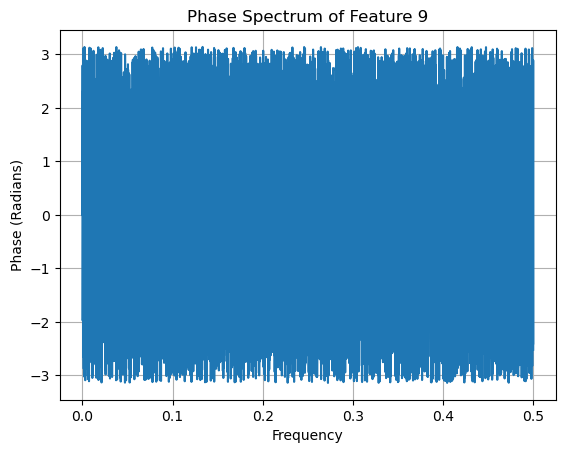

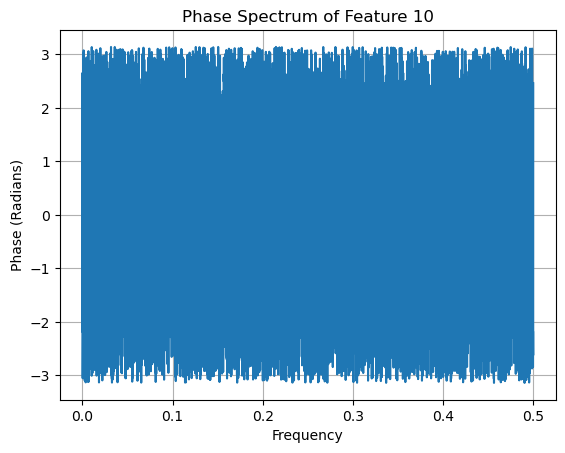

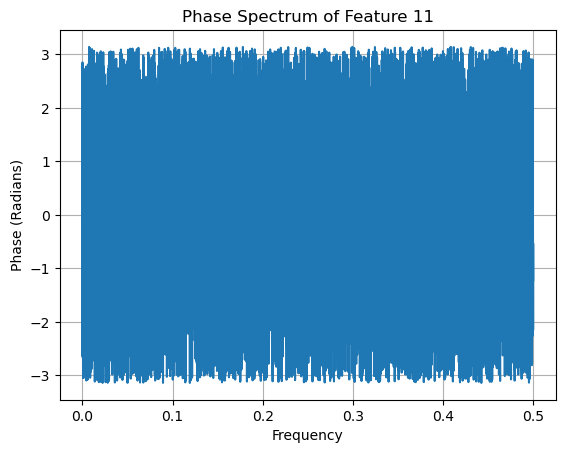

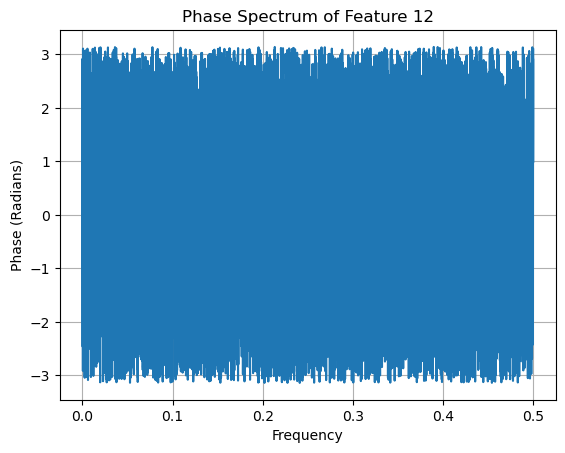

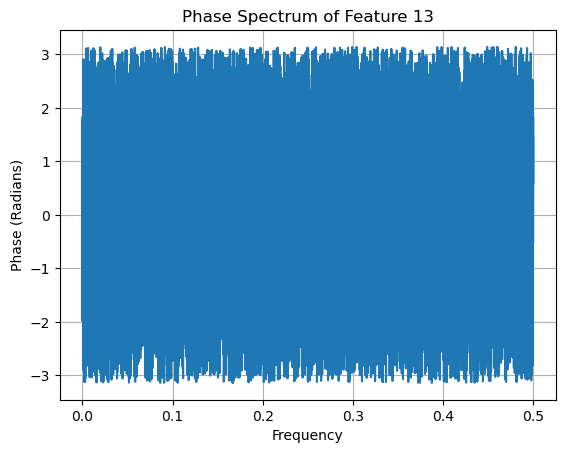

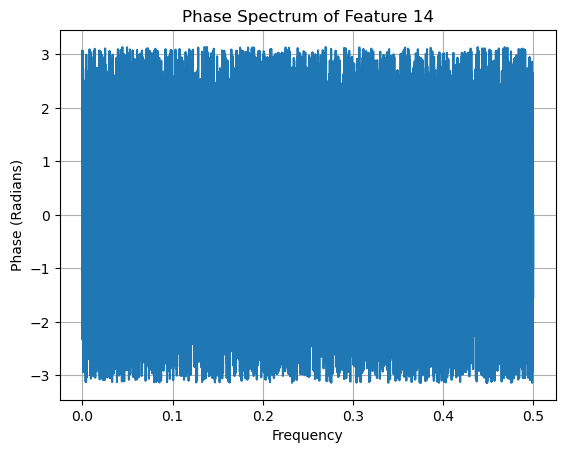

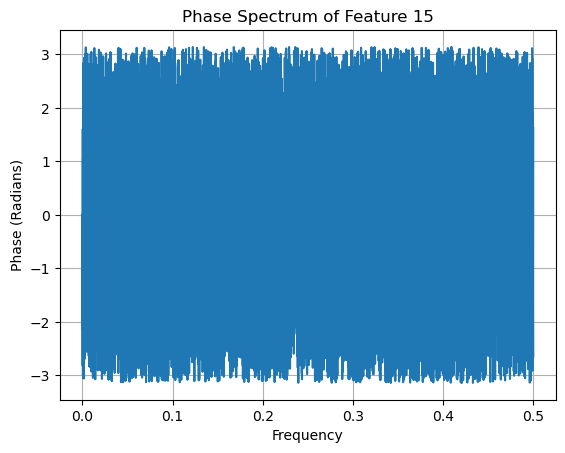

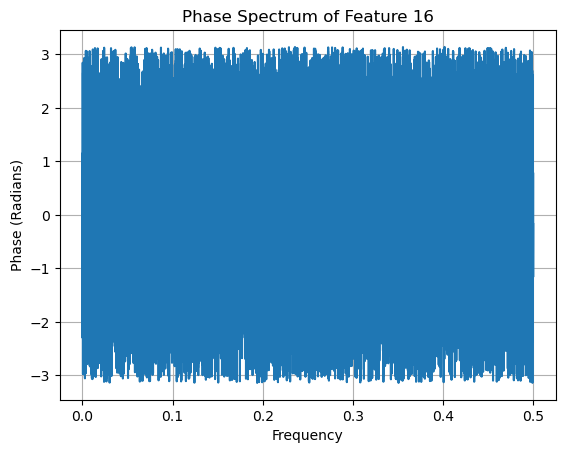

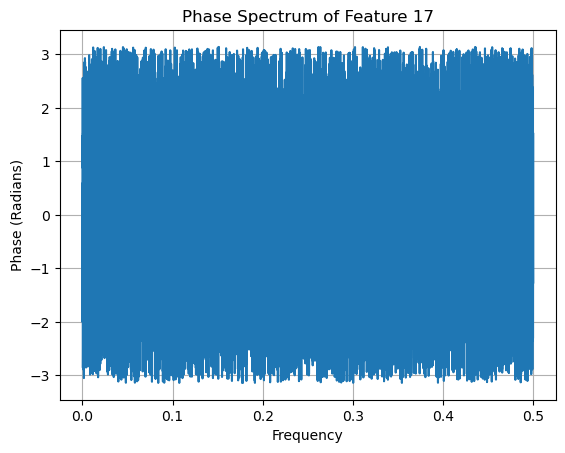

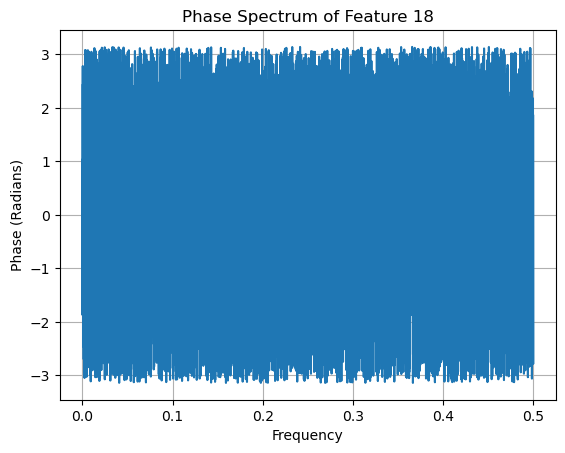

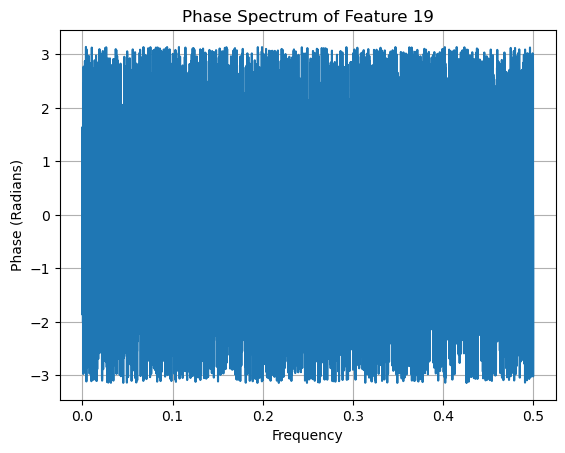

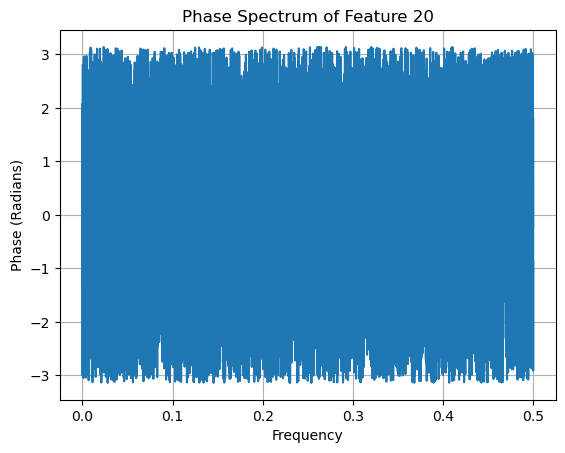

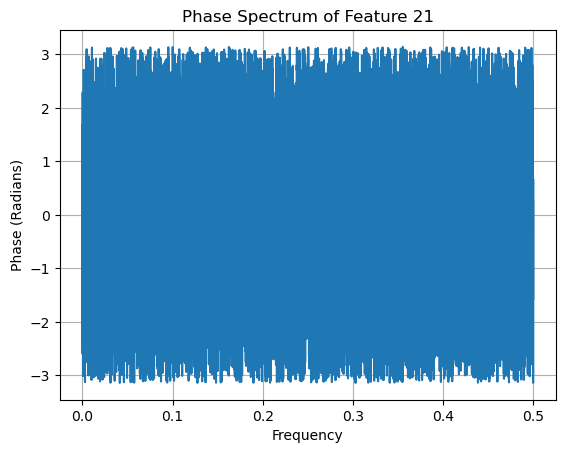

In [7]:
for j in range(Y.shape[1]):
    plt.figure()
    plt.plot(freqs[:len(freqs)//2], Y_fft_phase[:len(freqs)//2, j].numpy())
    plt.title(f'Phase Spectrum of Feature {j}')
    plt.xlabel('Frequency')
    plt.ylabel('Phase (Radians)')
    plt.grid()
    plt.show()


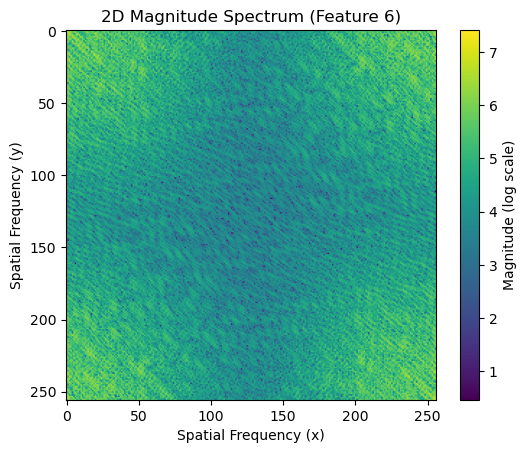

In [8]:
# Visualize magnitude spectrum for spatial data
plt.imshow(np.log1p(np.abs(Y_grid_fft[:, :, 6])), cmap='viridis')
plt.title('2D Magnitude Spectrum (Feature 6)')
plt.colorbar(label='Magnitude (log scale)')
plt.xlabel('Spatial Frequency (x)')
plt.ylabel('Spatial Frequency (y)')
plt.show()


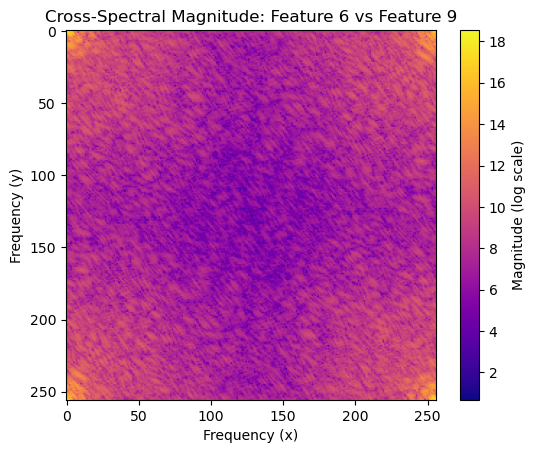

In [9]:
feature1, feature2 = 6, 9  # Example: Cross spectral analysis between feature 0 and 1
cross_spectral_magnitude = np.abs(cross_spectral_density)

plt.imshow(np.log1p(cross_spectral_magnitude), cmap='plasma')
plt.title(f'Cross-Spectral Magnitude: Feature {feature1} vs Feature {feature2}')
plt.colorbar(label='Magnitude (log scale)')
plt.xlabel('Frequency (x)')
plt.ylabel('Frequency (y)')
plt.show()


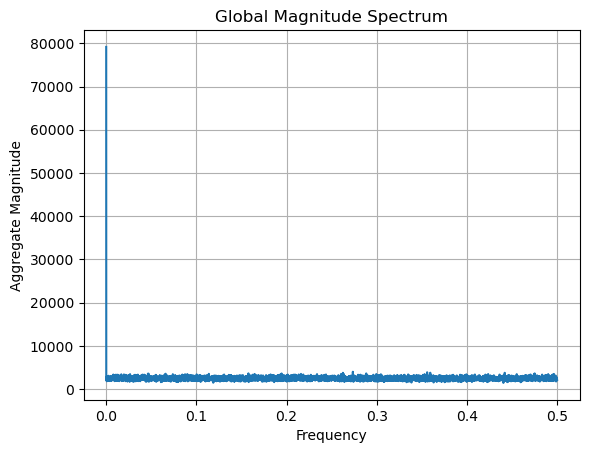

In [10]:
# Aggregate spectra
global_magnitude = Y_fft_magnitude.sum(dim=1)

plt.plot(freqs[:len(freqs)//2], global_magnitude[:len(freqs)//2].numpy())
plt.title('Global Magnitude Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Aggregate Magnitude')
plt.grid()
plt.show()


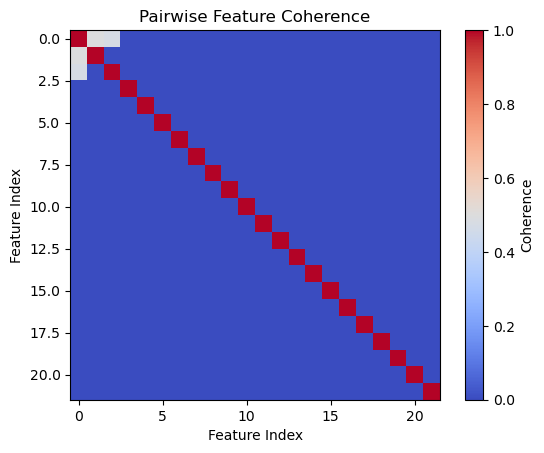

In [11]:
from scipy.signal import coherence

n_features = Y.shape[1]
coherence_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(i, n_features):
        f, coh = coherence(Y[:, i].numpy(), Y[:, j].numpy())
        if coh.mean()<0.4:
            coherence_matrix[i, j] = coherence_matrix[j, i] = 0
        else:
            coherence_matrix[i, j] = coherence_matrix[j, i] = coh.mean()

plt.imshow(coherence_matrix, cmap='coolwarm')
plt.colorbar(label='Coherence')
plt.title('Pairwise Feature Coherence')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()


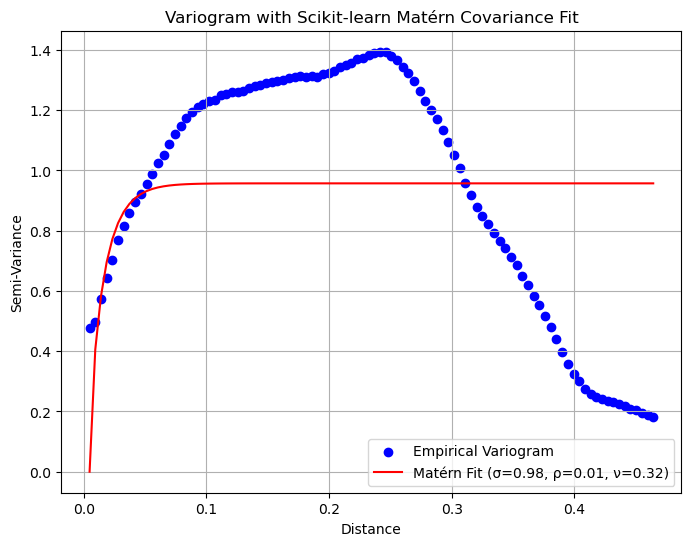

No strong evidence of long-range dependency.


In [12]:
import numpy as np
import torch
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit
from sklearn.gaussian_process.kernels import Matern
import matplotlib.pyplot as plt

# Select one feature for analysis
feature_idx = 0
values = Y[:, feature_idx]

# Step 1: Compute Pairwise Distances
distances = pdist(X)  # Pairwise distances between spatial coordinates
dist_matrix = squareform(distances)

# Step 2: Compute Semi-Variance
def compute_semivariance(distances, values, max_dist, num_bins):
    bins = np.linspace(0, max_dist, num_bins + 1)
    semi_variance = np.zeros(num_bins)
    counts = np.zeros(num_bins)
    
    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            dist = dist_matrix[i, j]
            if dist < max_dist:
                bin_idx = np.digitize(dist, bins) - 1
                semi_variance[bin_idx] += (values[i] - values[j])**2
                counts[bin_idx] += 1
                
    semi_variance /= 2 * counts
    return bins[1:], semi_variance

# Set parameters for analysis
max_dist = np.percentile(distances, 95)  # Maximum distance to consider
num_bins = 100  # Number of bins for variogram

# Compute bins and semi-variance
bins, semi_variance = compute_semivariance(distances, values, max_dist, num_bins)

# Step 3: Variogram from Scikit-learn Matérn Kernel
def variogram_from_sklearn_matern(h, sigma, rho, nu):
    """Variogram derived from sklearn's Matern kernel."""
    matern_kernel = Matern(length_scale=rho, nu=nu)
    h = h.reshape(-1, 1)  # Reshape distances to 2D for Matern
    matern_cov = matern_kernel(h)[:, 0]  # Evaluate kernel and flatten the result
    return sigma**2 * (1 - matern_cov)  # Variogram is 1 - normalized covariance

# Initial guesses for [sigma, rho, nu]
initial_guess = [np.sqrt(np.max(semi_variance)), max_dist / 3, 0.5]

# Fit the variogram using curve_fit
bounds = ([0, 1e-10, 0.1], [np.inf, np.inf, 5.0])  # Positive bounds and reasonable nu range
params, _ = curve_fit(
    lambda h, sigma, rho, nu: variogram_from_sklearn_matern(h, sigma, rho, nu),
    bins,
    semi_variance,
    p0=initial_guess,
    bounds=bounds,
)

# Extract fitted parameters
sigma_fitted, rho_fitted, nu_fitted = params

# Step 4: Visualization
plt.figure(figsize=(8, 6))
plt.scatter(bins, semi_variance, label='Empirical Variogram', color='blue')
plt.plot(
    bins,
    variogram_from_sklearn_matern(bins, sigma_fitted, rho_fitted, nu_fitted),
    label=f'Matérn Fit (σ={sigma_fitted:.2f}, ρ={rho_fitted:.2f}, ν={nu_fitted:.2f})',
    color='red',
)
plt.title('Variogram with Scikit-learn Matérn Covariance Fit')
plt.xlabel('Distance')
plt.ylabel('Semi-Variance')
plt.legend()
plt.grid()
plt.show()

# Step 5: Interpretation of Long-Range Dependency
if rho_fitted > max_dist / 2:
    print("Evidence of long-range dependency detected.")
else:
    print("No strong evidence of long-range dependency.")


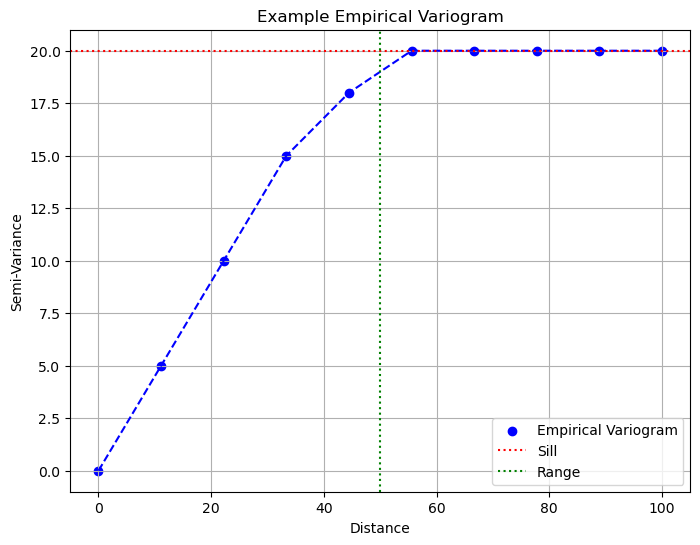

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated example data for bins and semi-variance
bins = np.linspace(0, 100, 10)  # Distances
semi_variance = np.array([0, 5, 10, 15, 18, 20, 20, 20, 20, 20])  # Semi-variance values

# Plot the empirical variogram
plt.figure(figsize=(8, 6))
plt.scatter(bins, semi_variance, color='blue', label='Empirical Variogram')
plt.plot(bins, semi_variance, color='blue', linestyle='--')
plt.axhline(y=20, color='red', linestyle=':', label='Sill')
plt.axvline(x=50, color='green', linestyle=':', label='Range')
plt.title('Example Empirical Variogram')
plt.xlabel('Distance')
plt.ylabel('Semi-Variance')
plt.legend()
plt.grid()
plt.show()

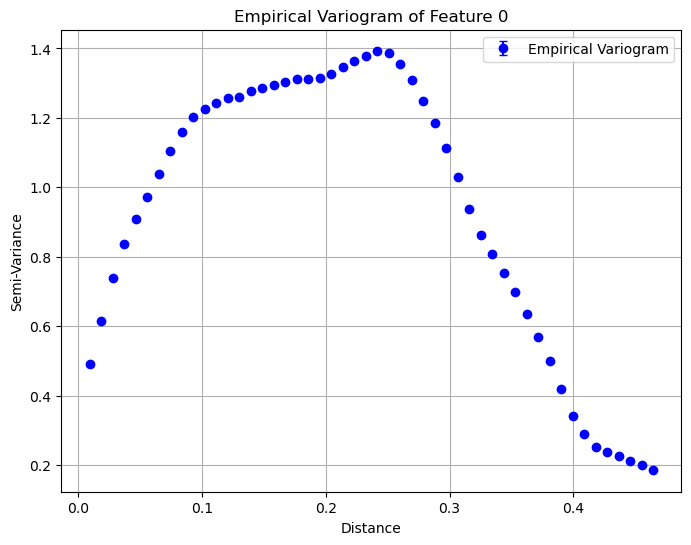

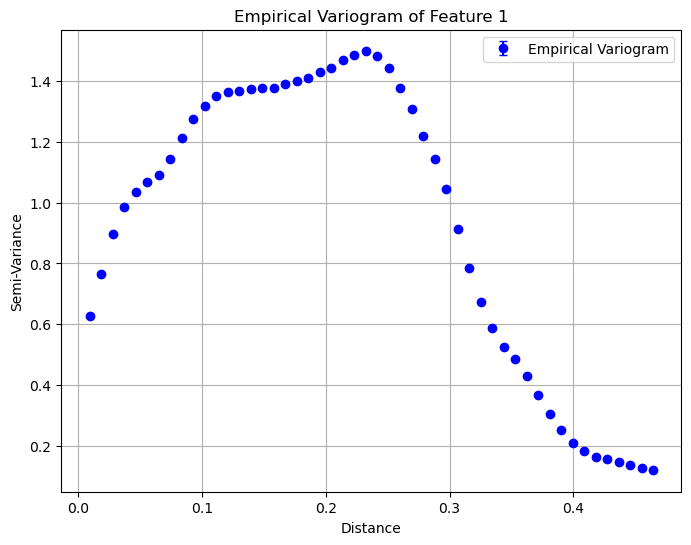

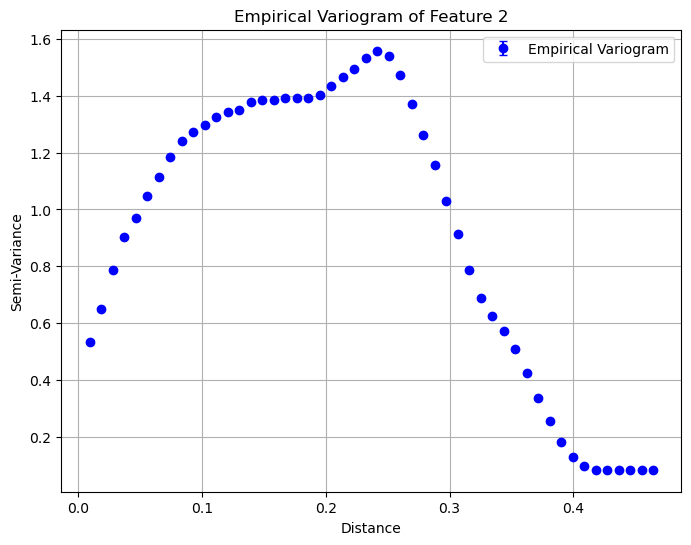

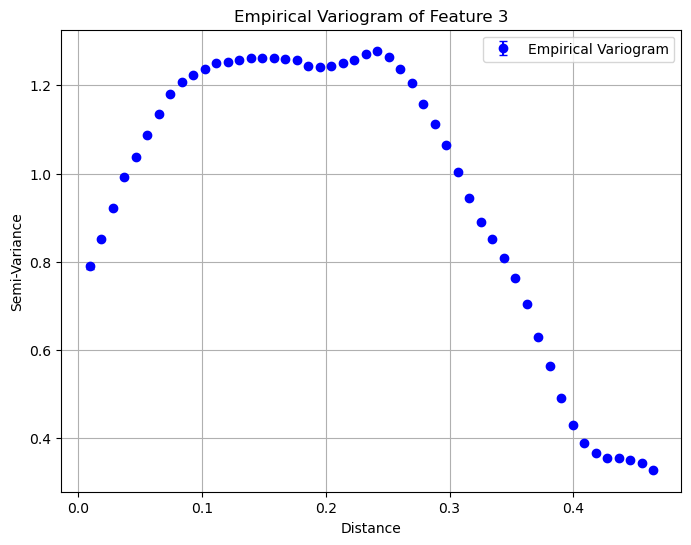

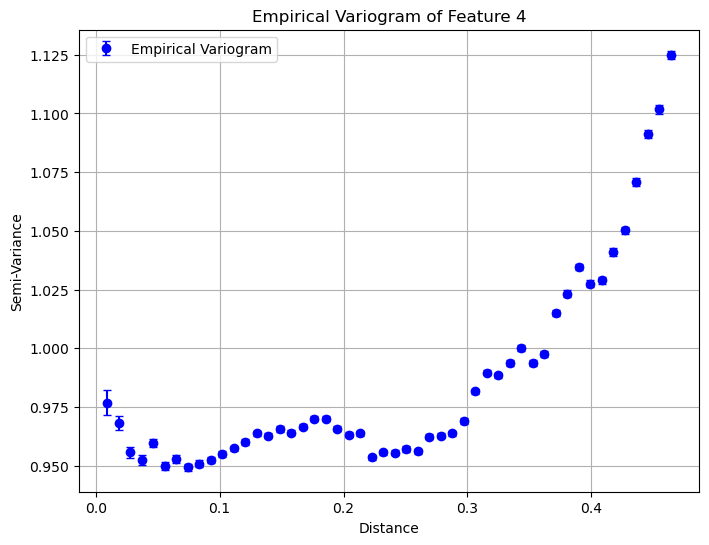

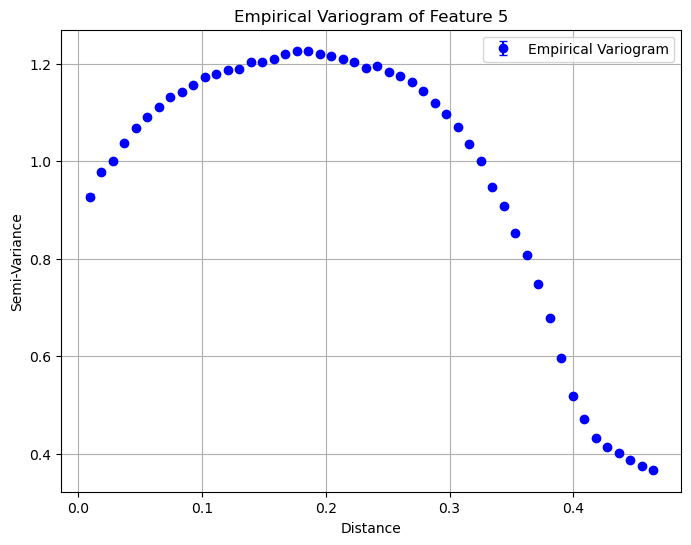

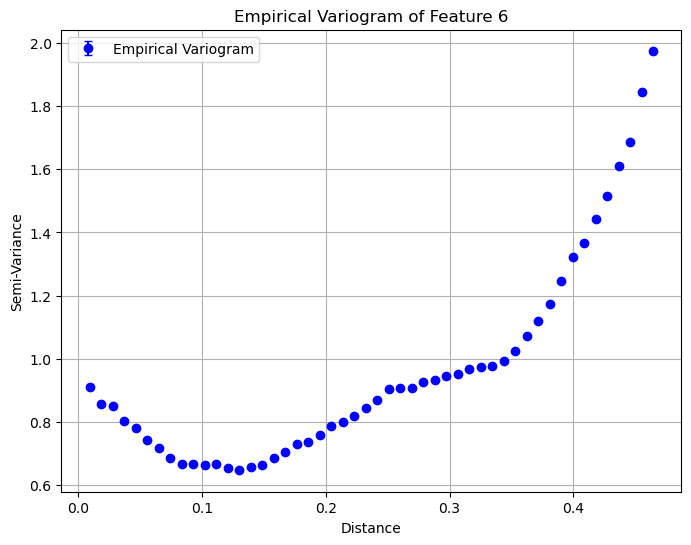

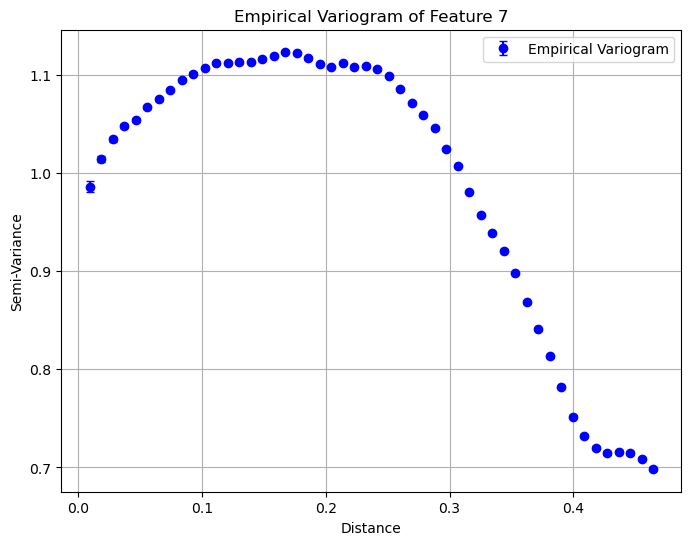

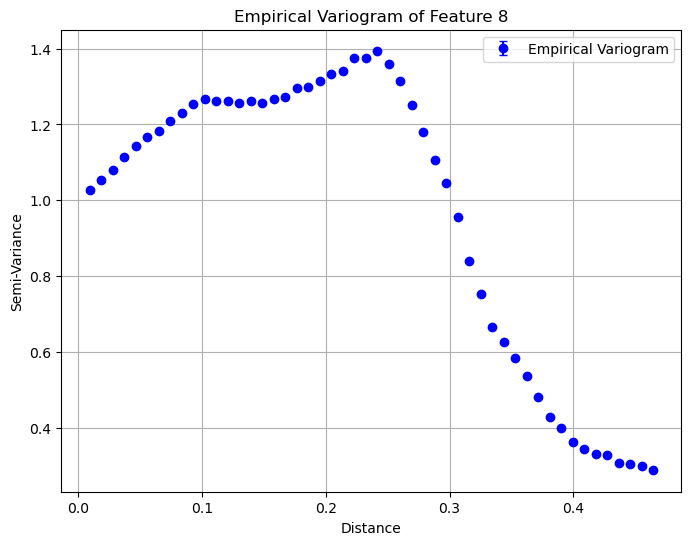

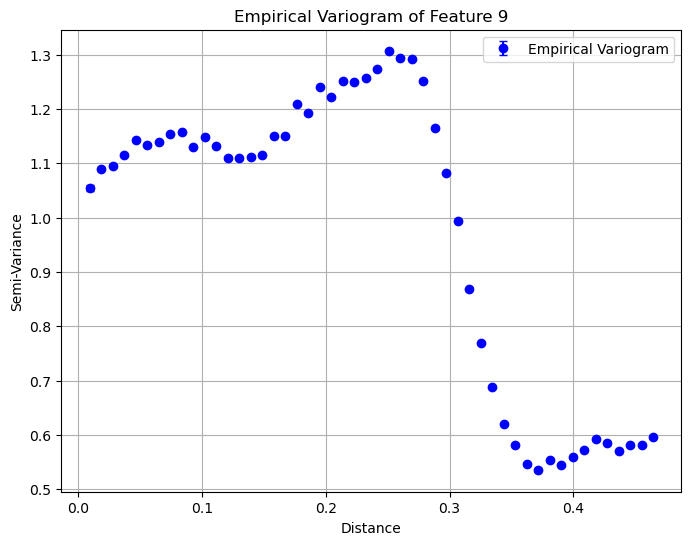

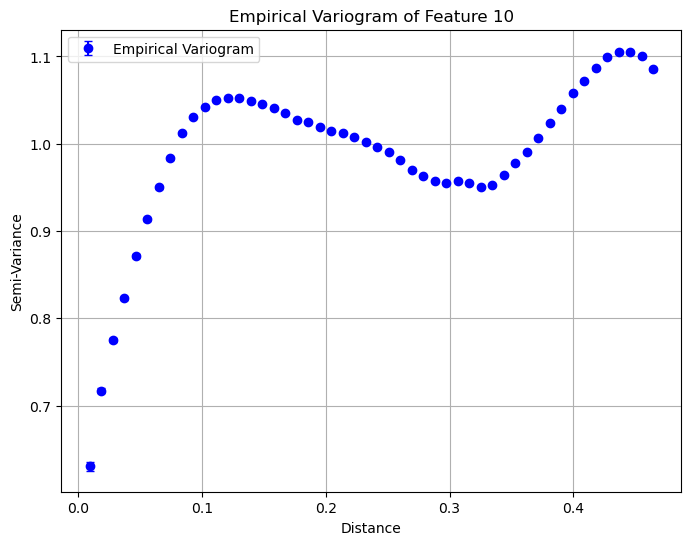

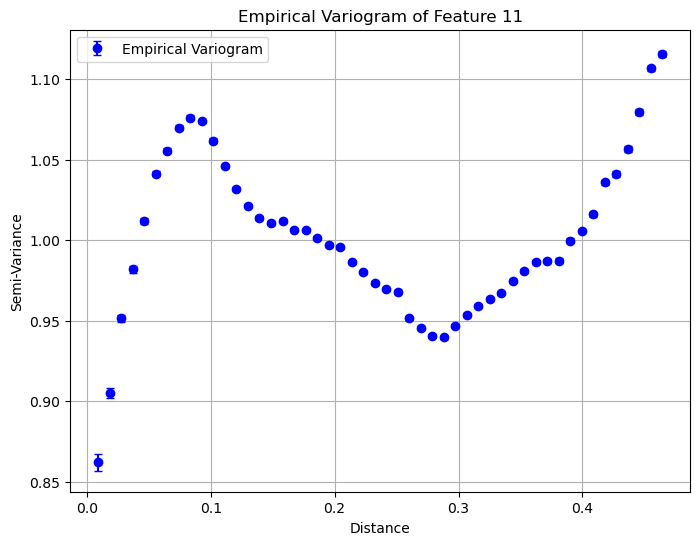

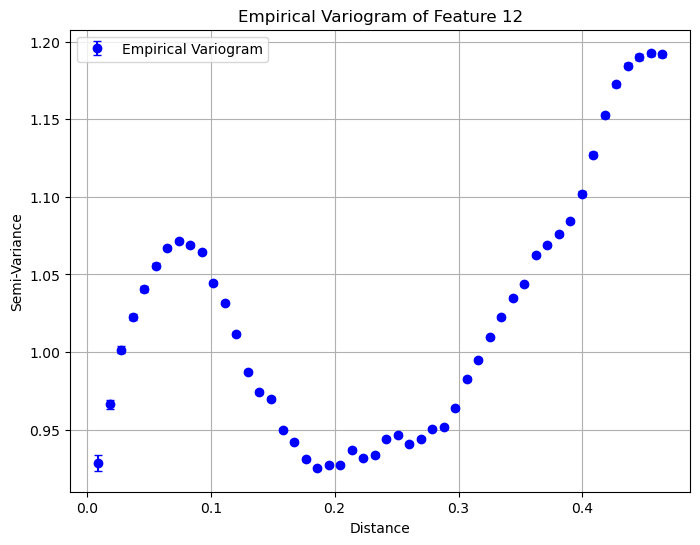

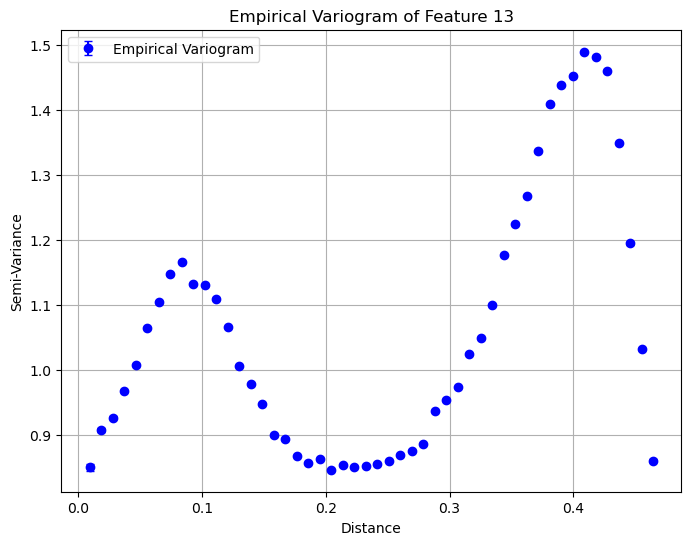

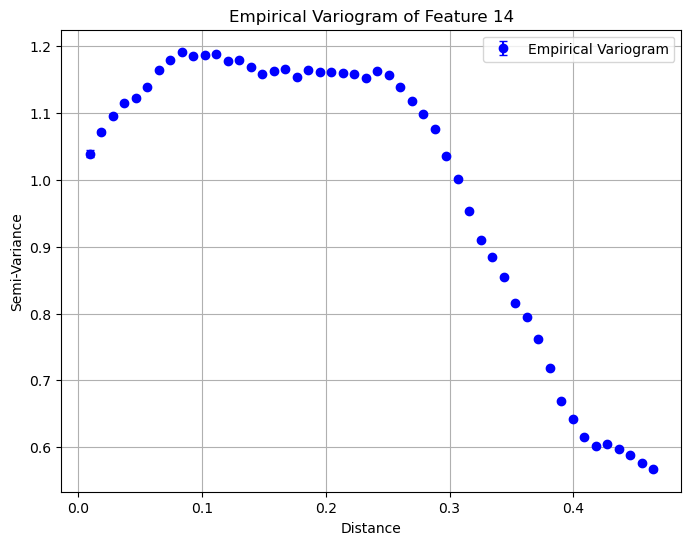

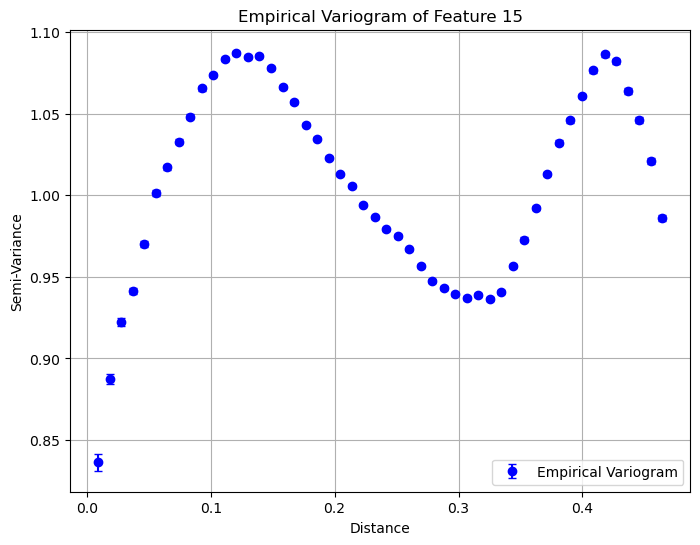

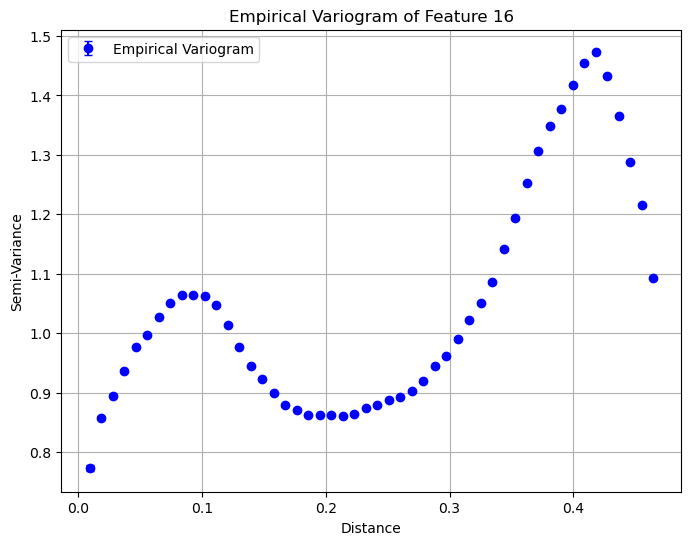

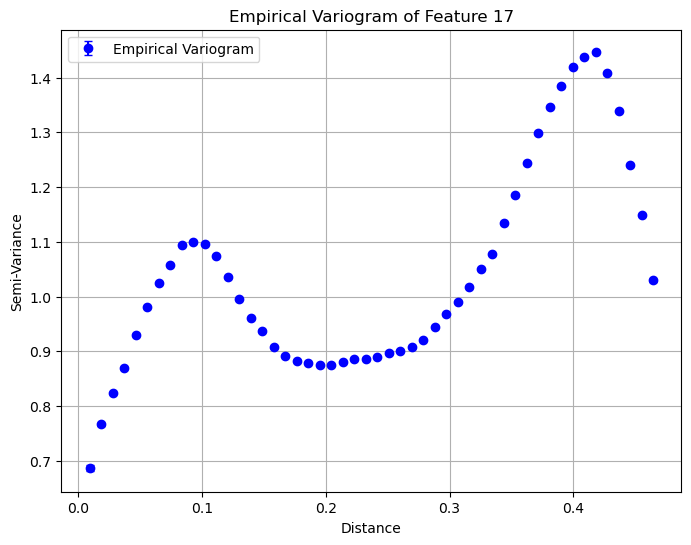

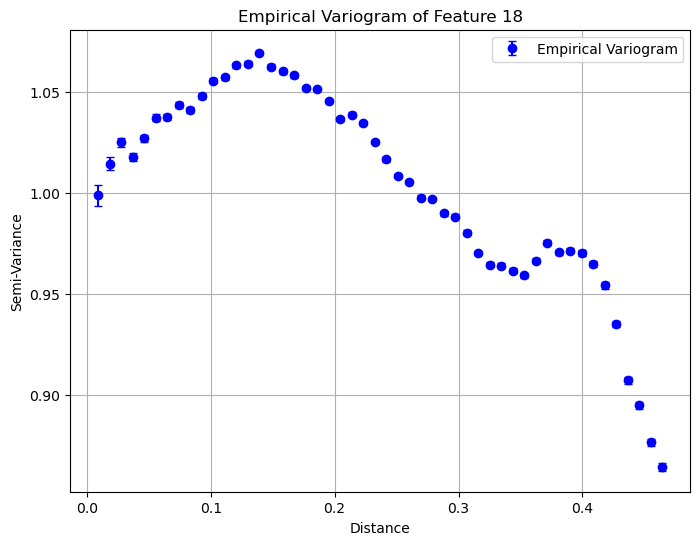

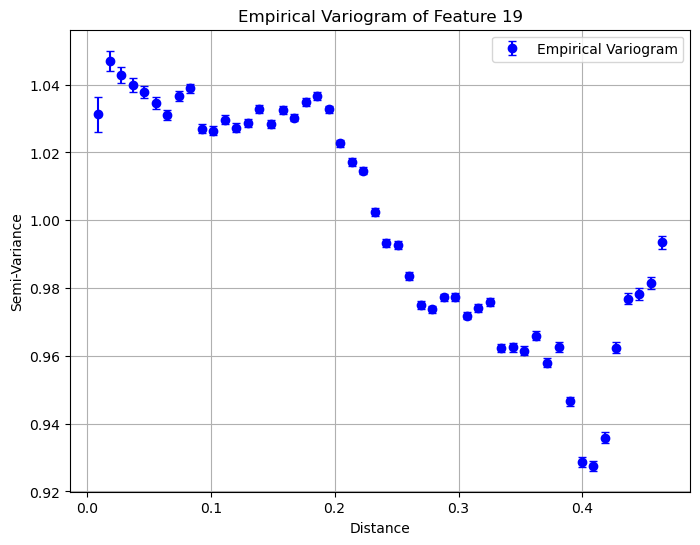

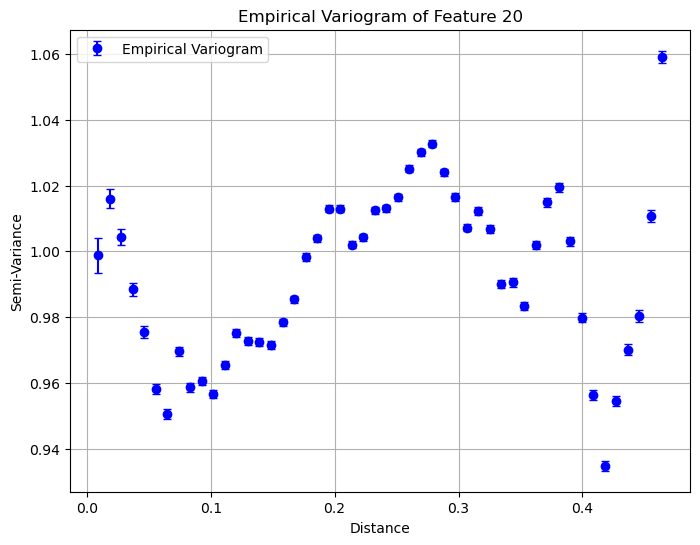

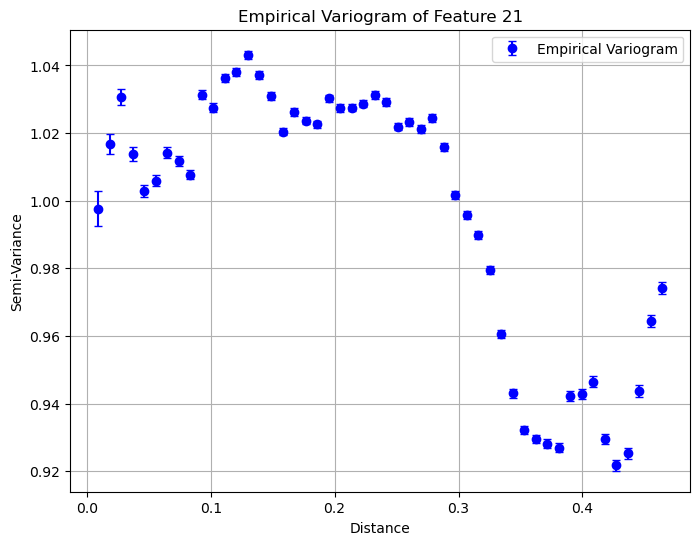

In [14]:
import numpy as np
import torch
from scipy.spatial.distance import pdist, squareform
from sklearn.gaussian_process.kernels import Matern
import matplotlib.pyplot as plt

# Select one feature for analysis
for feature_idx in range(22):
    values = Y[:, feature_idx]
    # Step 1: Compute Pairwise Distances
    distances = pdist(X)  # Pairwise distances between spatial coordinates
    dist_matrix = squareform(distances)
    
    # Step 2: Compute Semi-Variance
    def compute_semivariance(distances, values, max_dist, num_bins):
        bins = np.linspace(0, max_dist, num_bins + 1)
        semi_variance = np.zeros(num_bins)
        counts = np.zeros(num_bins)
        
        for i in range(len(values)):
            for j in range(i + 1, len(values)):
                dist = dist_matrix[i, j]
                if dist < max_dist:
                    bin_idx = np.digitize(dist, bins) - 1
                    semi_variance[bin_idx] += (values[i] - values[j])**2
                    counts[bin_idx] += 1
                    
        semi_variance /= 2 * counts
        return bins[1:], semi_variance, counts
    
    # Set parameters for analysis
    max_dist = np.percentile(distances, 95)  # Maximum distance to consider
    num_bins = 50  # Number of bins for variogram
    
    # Compute bins, semi-variance, and counts
    bins, semi_variance, counts = compute_semivariance(distances, values, max_dist, num_bins)
    
    # Step 3: Compute Uncertainty
    uncertainty = counts**(-0.5)*2
    uncertainty[np.isinf(uncertainty)] = 0  # Handle cases with zero counts
    
    # Step 4: Visualization
    plt.figure(figsize=(8, 6))
    plt.errorbar(bins, semi_variance, yerr=uncertainty, fmt='o', label='Empirical Variogram', color='blue', capsize=3)
    plt.title(f'Empirical Variogram of Feature {feature_idx}')
    plt.xlabel('Distance')
    plt.ylabel('Semi-Variance')
    plt.legend()
    plt.grid()
    plt.show()


In [15]:
len(X)

15907